# Notebook 07 — CARMA(3,1) Estimation and Lévy Recovery — Log-Price

Estimates a CARMA$(3,1)$ model for deseasonalized, jump-cleaned log-price residuals $\tilde{S}_t$ via quasi-maximum likelihood (yuima::qmle, L-BFGS-B, $h = 1/8760$ yr). Recovers Lévy driving increments $\Delta L^X$ using the same stationary Kalman filter + canonical-state formula (16) as notebook 06. Fits a NIG distribution to $\Delta L^X$.

> **Implementation note:** Same custom Kalman-based replacement for yuima's `CarmaNoise` as in notebook 06 — see that notebook for the rationale.

**Inputs:** `data/deseasonalised/price_resid.csv`  
**Outputs:** `data/levy/price_levy_increments.csv`

### Step 1 — ARIMA(3,0,2) baseline fit

Fits a discrete-time ARIMA(3,0,2) model to the zero-mean deseasonalized, jump-cleaned log-price residuals as a preliminary diagnostic. The estimated AR/MA coefficients cross-check the CARMA$(3,2)$ eigenvalues from notebook 04 and provide hourly-scale starting values for the QMLE in Steps 2–3.

In [1]:
# Load data
price_resid <- read.csv("../data/deseasonalised/price_resid.csv", row.names = 1)

# Jump-cleaned deseasonalized log-price series
price_res <- price_resid$price_deseasoned

# Fit ARIMA(3,0,1) without mean
price_model <- arima(price_res, order = c(3, 0, 2), include.mean = FALSE, method = "CSS-ML")

# Coefficients and standard errors
coef(price_model)
aic <- price_model$aic
cat(sprintf("AIC = %.2f\n", aic))
se <- sqrt(diag(price_model$var.coef))
print(se)
summary(price_model)

ar1        ar2        ar3        ma1        ma2 
0.09633855 0.56959657 0.16960916 1.02533604 0.31316342

AIC = -166286.86
       ar1        ar2        ar3        ma1        ma2 
0.16514726 0.14785293 0.02639522 0.16512450 0.04680860 


          Length Class  Mode     
coef          5  -none- numeric  
sigma2        1  -none- numeric  
var.coef     25  -none- numeric  
mask          5  -none- logical  
loglik        1  -none- numeric  
aic           1  -none- numeric  
arma          7  -none- numeric  
residuals 26281  ts     numeric  
call          5  -none- call     
series        1  -none- character
code          1  -none- numeric  
n.cond        1  -none- numeric  
nobs          1  -none- numeric  
model        10  -none- list     

In [2]:
# Initial sigma calibration from Lyapunov equation
library(Matrix)

df <- read.csv("../data/deseasonalised/price_resid.csv", row.names = 1)
y  <- as.numeric(df[["price_deseasoned"]])
y  <- y[is.finite(y)]
y  <- y - mean(y)

a_init <- c(2.35598587, 1.06144002, 0.05395593)
b_init <- c(1, 0.5, 0.1)   # b0=1, b1, b2

p <- 3
A <- matrix(0, p, p)
for (i in 1:(p - 1)) A[i, i + 1] <- 1
A[p, ] <- -rev(a_init)

ep <- matrix(0, p, 1); ep[p] <- 1
Q  <- ep %*% t(ep)

Sigma_norm <- matrix(
  solve(kronecker(diag(p), A) + kronecker(A, diag(p)), -as.vector(Q)),
  p, p
)

b_vec    <- c(b_init, rep(0, p - length(b_init)))
var_norm <- t(b_vec) %*% Sigma_norm %*% b_vec
sig_init <- sd(y) / sqrt(var_norm)

cat(sprintf("sig_init = %.6f\n", sig_init))

sig_init = 0.011236


### Step 2 — QMLE at hourly scale (preliminary)

First-pass quasi-maximum likelihood estimation with $h = 1$ hr. The L-BFGS-B optimizer minimizes the negative Gaussian quasi-log-likelihood over $(a_1,a_2,a_3, b_0, b_1, \sigma)$. An initial $\sigma$ is obtained from the Lyapunov equation (see cell below). Results are rescaled to yr⁻¹ in Step 3 for the final model.

In [3]:
library(yuima)

df <- read.csv("../data/deseasonalised/price_resid.csv", row.names= 1)
y  <- as.numeric(df[["price_deseasoned"]])
y  <- y[is.finite(y)]
y  <- y - mean(y)
h  <- 1

dat <- setData(matrix(y, ncol = 1), delta = h)
mod <- setCarma(p = 3, q = 2, scale.par = "sig", Carma.var = "y")
yu  <- setYuima(model = mod, data = dat)

# Starting values at hourly scale (h = 1)
start <- list(
  a1  = 2.35598587 ,
  a2  = 1.06144002  ,
  a3  = 0.05395593,
  b0  = 1,
  b1  = 0.5,
  b2=0.1,
  sig = 0.011236
)

cat("=== INITIAL PARAMETERS (h = 1 hr) ===\n")
for (nm in names(start)) cat(sprintf("  %-4s = %g\n", nm, start[[nm]]))

est <- suppressWarnings(qmle(yuima = yu, start = start,
                             lower = list(sig = 1e-6),
                             method = "L-BFGS-B"))

cf       <- coef(est)
loglik   <- -est@min
n_params <- length(cf)
aic      <- 2 * n_params - 2 * loglik

cat("\n=== ESTIMATED PARAMETERS (h = 1 hr) ===\n")
for (nm in names(cf)) cat(sprintf("  %-4s = %g\n", nm, cf[[nm]]))

cat(sprintf("\n=== FIT CRITERIA ===\n"))
cat(sprintf("  log-lik  = %.4f\n", loglik))
cat(sprintf("  n_params = %d\n",   n_params))
cat(sprintf("  AIC      = %.4f\n", aic))

Le chargement a nécessité le package : zoo


Attachement du package : 'zoo'


Les objets suivants sont masqués depuis 'package:base':

    as.Date, as.Date.numeric


Le chargement a nécessité le package : stats4

Le chargement a nécessité le package : expm


Attachement du package : 'expm'


L'objet suivant est masqué depuis 'package:Matrix':

    expm


Le chargement a nécessité le package : cubature

Le chargement a nécessité le package : mvtnorm

########################################

This is YUIMA Project package v.1.15.34

Why don't you try yuimaGUI package?

Visit: http://www.yuima-project.com

########################################


Attachement du package : 'yuima'


L'objet suivant est masqué depuis 'package:stats':

    simulate




=== INITIAL PARAMETERS (h = 1 hr) ===
  a1   = 2.35599
  a2   = 1.06144
  a3   = 0.0539559
  b0   = 1
  b1   = 0.5
  b2   = 0.1
  sig  = 0.011236

Starting qmle for carma ... 

=== ESTIMATED PARAMETERS (h = 1 hr) ===
  sig  = 0.0230633
  b2   = 0.0856061
  b0   = 1
  b1   = -1.69107
  a3   = 0.161164
  a2   = 1.85827
  a1   = 2.74174

=== FIT CRITERIA ===
  log-lik  = 78258.6737
  n_params = 7
  AIC      = -156503.3474


In [4]:

cf     <- coef(est)
ar.par <- c(cf["a1"], cf["a2"], cf["a3"])
ma.par <- c(cf["b0"], cf["b1"], cf["b2"]) * cf["sig"]

dir.create("../data/kalman", showWarnings = FALSE, recursive = TRUE)

write.csv(
  data.frame(
    name  = c("a1","a2","a3","b0","b1","b2","sig",
              "ma0","ma1","ma2"),
    value = c(cf["a1"],cf["a2"],cf["a3"],
              cf["b0"],cf["b1"],cf["b2"],cf["sig"],
              ma.par[1],ma.par[2],ma.par[3])
  ),
  "../data/kalman/price_carma_params.csv",
  row.names = FALSE
)
cat("Saved price_carma_params.csv\n")
print(read.csv("../data/kalman/price_carma_params.csv"))

Saved price_carma_params.csv
   name       value
1    a1  2.74173685
2    a2  1.85827343
3    a3  0.16116359
4    b0  1.00000000
5    b1 -1.69107500
6    b2  0.08560607
7   sig  0.02306331
8   ma0  0.02306331
9   ma1 -0.03900179
10  ma2  0.00197436


### Lévy increment recovery — custom Kalman + formula (16)

Same stationary Kalman filter approach as notebook 06. For CARMA$(3,1)$ the AR polynomial has three eigenvalues; the one with the largest real part and $b(\lambda_r) \neq 0$ is selected as the dominant eigenvalue. If all eigenvalues are complex, the real part of the first eigenvalue is used as a fallback.


=== AIC COMPARISON ===
  Gaussian AIC : 56202.1
  NIG AIC      : 42271.8
  Merton AIC   : 43695.8


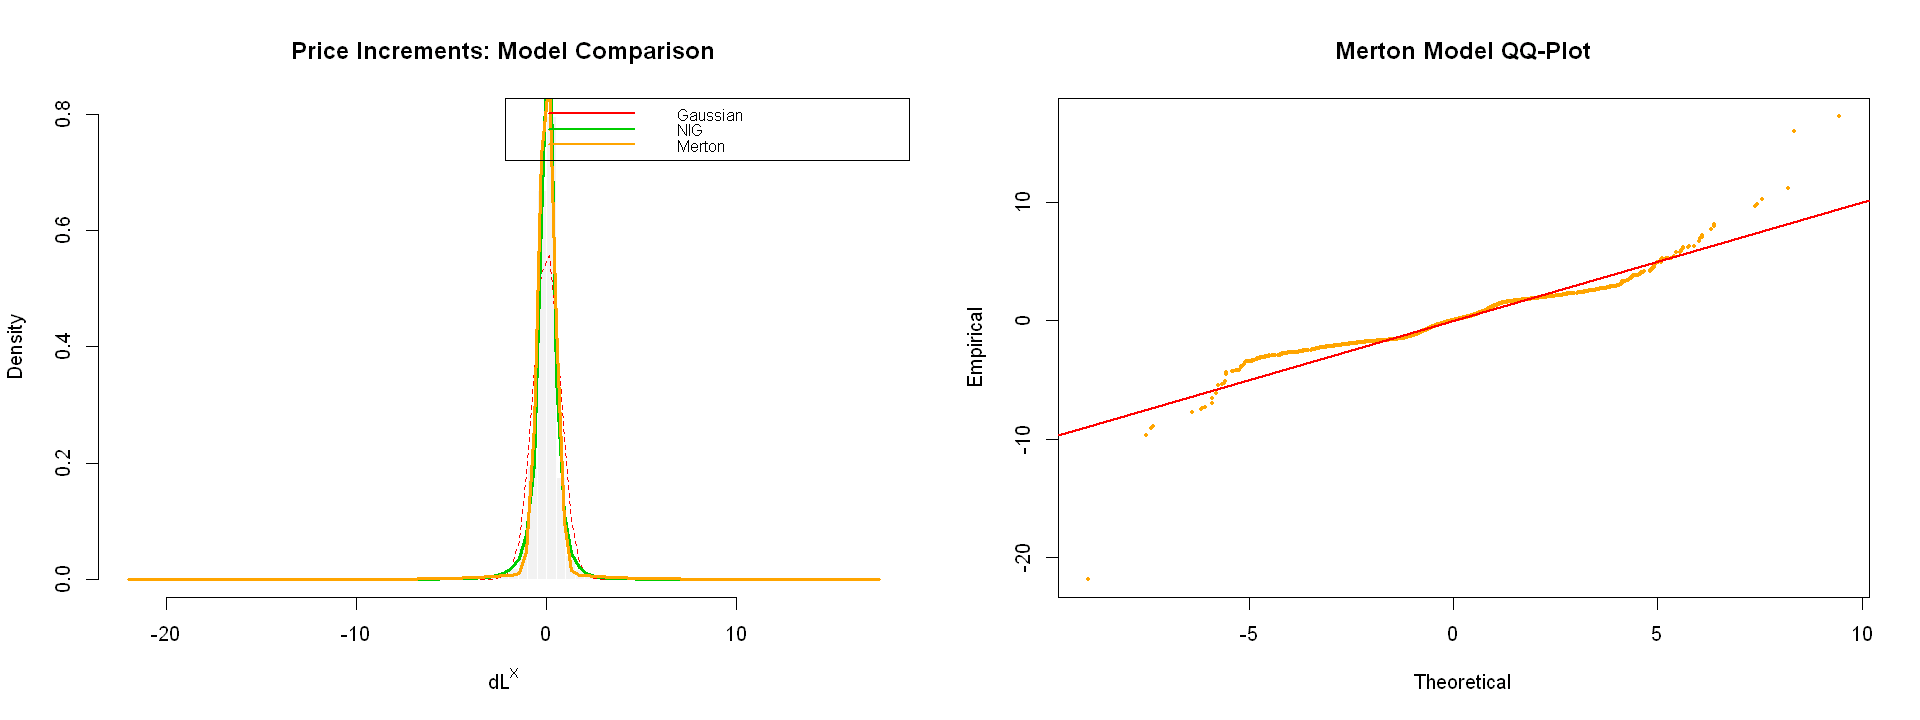

In [8]:
library(expm)
library(GeneralizedHyperbolic)

# ==============================================================================
# 1. CARMA PARAMETERS & DATA LOADING
# ==============================================================================
# Parameters from the previous QMLE estimation
cf     <- coef(est)
ar.par <- c(cf["a1"], cf["a2"], cf["a3"])
ma.par <- c(cf["b0"], cf["b1"], cf["b2"]) * cf["sig"]
p      <- length(ar.par)
q      <- length(ma.par)
h      <- 1 # Daily time step

# Load price data
df <- read.csv("../data/deseasonalised/price_resid.csv", row.names = 1)
y  <- as.numeric(df[["price_deseasoned"]])
y  <- y[is.finite(y)]
y  <- y - mean(y) # Center the series
n  <- length(y)

# ==============================================================================
# 2. STATE-SPACE MATRICES & KALMAN FILTER
# ==============================================================================
# Companion matrix A [cite: 120, 591]
A <- matrix(0, p, p)
if (p > 1) for (i in 1:(p - 1)) A[i, i + 1] <- 1
A[p, ] <- -ar.par[p:1]

b_vec  <- rep(0, p); b_vec[1:q] <- ma.par
e_p    <- rep(0, p); e_p[p]     <- 1
eAh    <- expm(A * h)

# Stationary Kalman Gain
Q_proc <- (e_p %o% e_p) * h
P_ss   <- matrix(0, p, p)
for (k in 1:1000) { # Lyapunov iteration for steady state covariance
  P_ss <- eAh %*% P_ss %*% t(eAh) + Q_proc
}
S_ss   <- as.numeric(t(b_vec) %*% P_ss %*% b_vec) + 1e-10
K_stat <- (P_ss %*% b_vec) / S_ss

# Forward Pass (State Recovery) [cite: 130, 614]
X_f <- matrix(0, n, p)
for (i in 2:n) {
  Xp       <- as.numeric(eAh %*% X_f[i - 1, ])
  X_f[i, ] <- Xp + K_stat * (y[i] - sum(b_vec * Xp))
}

# ==============================================================================
# 3. LEVY INCREMENT RECOVERY (Brockwell et al., 2011)
# ==============================================================================
eig_A     <- eigen(A)
BinLambda <- sapply(eig_A$values, function(lam) sum(ma.par * lam^(0:(q - 1))))
Y_CVS     <- diag(BinLambda) %*% solve(eig_A$vectors) %*% t(X_f)

idx_r     <- which.max(Re(eig_A$values)) # Dominant eigenvalue
lambda_r  <- Re(eig_A$values[idx_r])
coeff     <- Re(sum(sapply(1:p, function(k) (p + 1 - k) * c(1, ar.par)[k] * lambda_r^(p - k))) / BinLambda[idx_r])

# Integration via trapezoid rule
Y_r     <- Re(Y_CVS[idx_r, ])
lev_und <- numeric(n); int_cum <- 0
for (t in 2:n) {
  int_cum    <- int_cum + 0.5 * (Y_r[t - 1] + Y_r[t]) * h
  lev_und[t] <- coeff * (Y_r[t] - Y_r[1] - lambda_r * int_cum)
}
dL <- diff(lev_und) # Recovered increments dL^X

# ==============================================================================
# 4. DISTRIBUTION FITTING (GAUSSIAN, NIG, MERTON)
# ==============================================================================
# 4.1. Gaussian Fit (Benchmark) [cite: 40]
mu_nor    <- mean(dL)
sigma_nor <- sd(dL)

# 4.2. NIG Fit (Original Model) [cite: 176]
fit_nig    <- suppressWarnings(nigFit(dL))
params_nig <- fit_nig$param

# 4.3. Merton Jump-Diffusion Fit (Threshold Method) [cite: 53, 179]
sigma_rob   <- median(abs(dL - median(dL))) / 0.6745 # Robust volatility
threshold   <- 3 * sigma_rob 
is_jump     <- abs(dL) > threshold
jumps       <- dL[is_jump]
non_jumps   <- dL[!is_jump]

# Parameters via Method of Moments
sigma_X_M  <- sd(non_jumps) / sqrt(h)
lambda_C_M <- sum(is_jump) / (n * h)
mu_J_M     <- if(length(jumps) > 0) mean(jumps) else 0
sigma_J_M  <- if(length(jumps) > 1) sd(jumps) else 0

# Merton PDF Function
dmerton <- function(x, sig_x, lam, mu_j, sig_j, dt, K=15) {
  dens <- 0
  for (k in 0:K) {
    p_k <- (exp(-lam * dt) * (lam * dt)^k) / factorial(k)
    v_k <- (sig_x^2 * dt) + (k * sig_j^2)
    dens <- dens + p_k * dnorm(x, mean = k * mu_j, sd = sqrt(v_k))
  }
  return(dens)
}

# ==============================================================================
# 5. VISUALIZATION & COMPARISON
# ==============================================================================
options(repr.plot.width = 16, repr.plot.height = 6)
par(mfrow = c(1, 2))

# Plot A: Histogram and Density Overlay
hist(dL, breaks = 80, freq = FALSE, col = "gray95", border = "white",
     main = "Price Increments: Model Comparison", xlab = expression(dL^X))
curve(dnorm(x, mu_nor, sigma_nor), add = TRUE, col = "red", lty = 2, lwd = 1.5)
curve(dnig(x, mu = params_nig["mu"], delta = params_nig["delta"],
           alpha = params_nig["alpha"], beta = params_nig["beta"]),
      add = TRUE, col = "green3", lwd = 2.5)
curve(dmerton(x, sigma_X_M, lambda_C_M, mu_J_M, sigma_J_M, h), 
      add = TRUE, col = "orange", lwd = 2.5)
legend("topright", c("Gaussian", "NIG", "Merton"), 
       col = c("red", "green3", "orange"), lwd = 2, cex = 0.8)

# Plot B: Tail Analysis (QQ-Plot for Merton)
q_merton <- sort(replicate(length(dL), {
  n_s <- rpois(1, lambda_C_M * h)
  sigma_X_M * sqrt(h) * rnorm(1) + sum(rnorm(n_s, mu_J_M, sigma_J_M))
}))
plot(q_merton, sort(dL), pch = 16, cex = 0.4, col = "orange",
     main = "Merton Model QQ-Plot", xlab = "Theoretical", ylab = "Empirical")
abline(0, 1, col = "red", lwd = 2)

# ==============================================================================
# 6. RESULTS SUMMARY
# ==============================================================================
ll_nor    <- sum(dnorm(dL, mu_nor, sigma_nor, log = TRUE))
ll_nig    <- sum(log(dnig(dL, mu = params_nig["mu"], delta = params_nig["delta"],
                          alpha = params_nig["alpha"], beta = params_nig["beta"])))
ll_merton <- sum(log(dmerton(dL, sigma_X_M, lambda_C_M, mu_J_M, sigma_J_M, h)))

cat("\n=== AIC COMPARISON ===\n")
cat(sprintf("  Gaussian AIC : %.1f\n", -2 * ll_nor + 2 * 2))
cat(sprintf("  NIG AIC      : %.1f\n", -2 * ll_nig + 2 * 4))
cat(sprintf("  Merton AIC   : %.1f\n", -2 * ll_merton + 2 * 4))

p_T = 2, p_X = 3, h = 1
e_p_T : 0 1
e_p_X : 0 0 1
C dimensions : 2 x 3
Sylvester M  : 6 x 6

--- TEMP ---
  obs   : 52607  [2020-01-01 01:00:00 -> 2025-12-31 23:00:00]
  dups  : 0

--- PRICE ---
  obs   : 26280  [2023-01-01 01:00:00 -> 2025-12-31 00:00:00]
  dups  : 0

--- MERGED ---
  obs   : 26280  [2023-01-01 01:00:00 -> 2025-12-31 00:00:00]
  NAs   : r_T=0  r_X=0
  spacing min/max: 1.00 / 1.00 hours
All alignment checks passed.

Computing K_TX via Sylvester...
  Sylvester: M is 6x6, vec(C) length 6
K_TX dimensions : 2 x 3
b_T' K_TX b_X = -0.00739987

numerator   = -0.00025248
denominator = -0.00739987
lambda_hat  = 0.034119
SE      = 0.007885
t-stat  = 4.3271
p-value = 0.000015
95% CI  = [0.018665, 0.049574]

  h          = 1 (hours)
  n_obs      = 26280
  sigma_T    = 1.441678
  lambda_hat = 0.034119
  SE         = 0.007885
  t-stat     = 4.3271
  p-value    = 0.000015


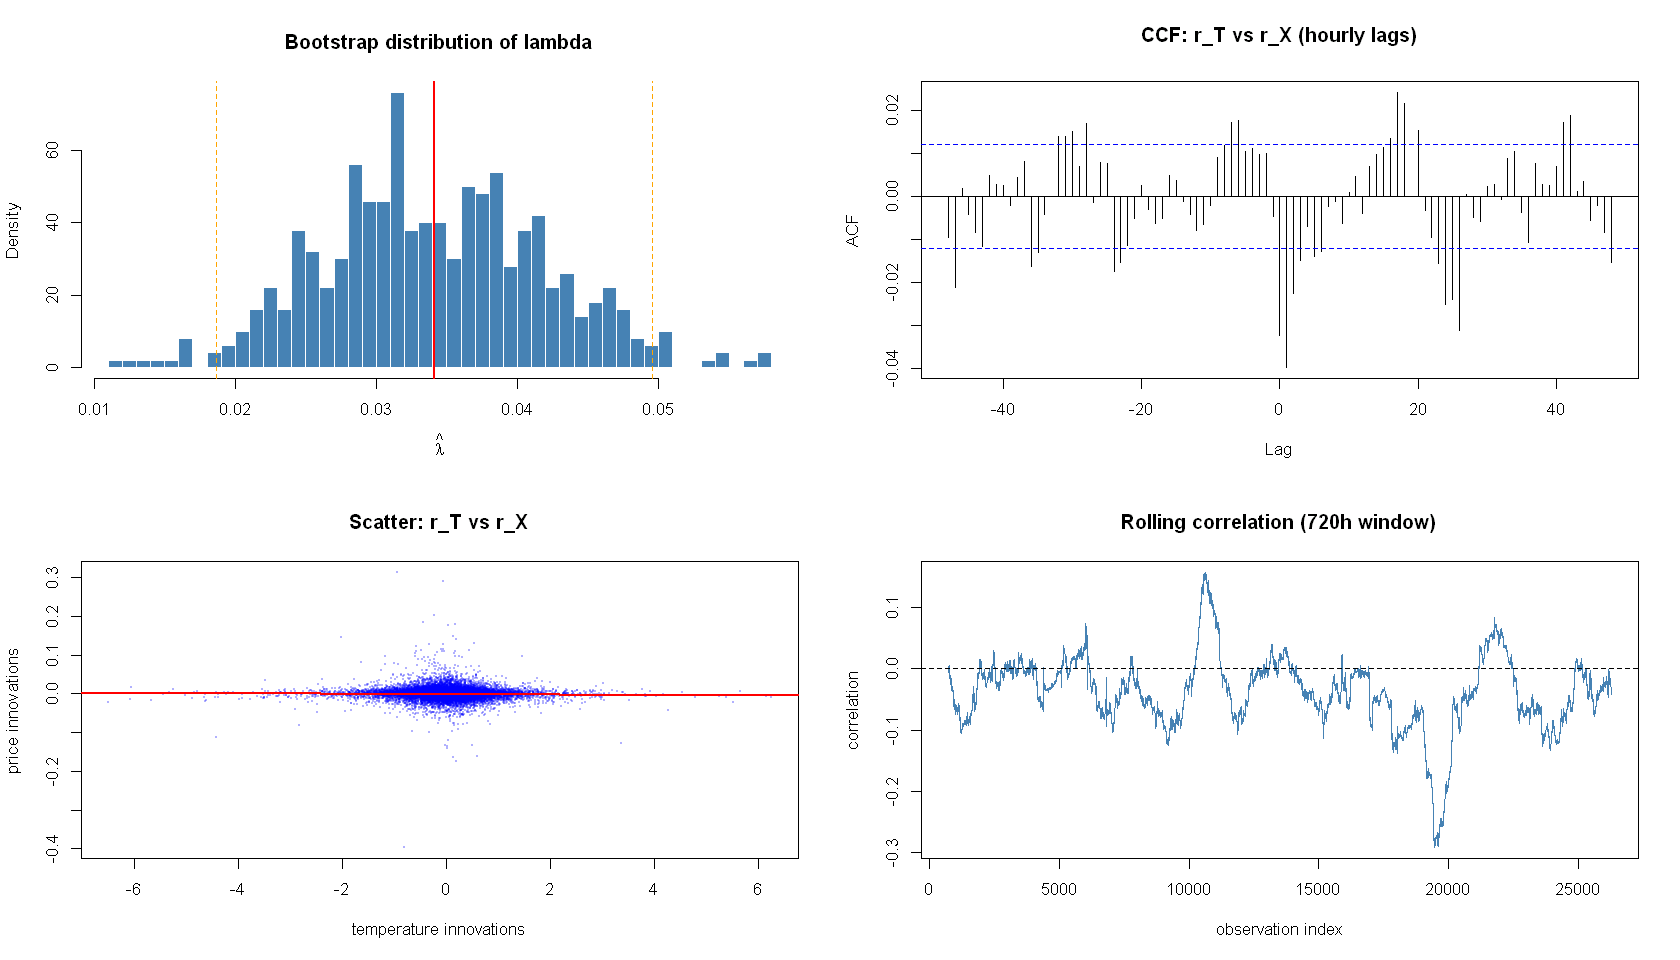

In [16]:
library(expm)

# --------------------------------------------------
# 1. Load
# --------------------------------------------------
temp  <- readRDS("../data/kalman/temp_kalman.rds")
price <- readRDS("../data/kalman/price_kalman.rds")

A_T     <- temp$A;    b_T <- temp$b_vec
A_X     <- price$A;   b_X <- price$b_vec
p_T     <- nrow(A_T); p_X <- nrow(A_X)
h       <- temp$h;    sigma_T <- temp$sigma_T

# Rebuild e_p from dimensions
e_p_T <- rep(0, p_T); e_p_T[p_T] <- 1
e_p_X <- rep(0, p_X); e_p_X[p_X] <- 1

cat(sprintf("p_T = %d, p_X = %d, h = %g\n", p_T, p_X, h))
cat(sprintf("e_p_T : %s\n", paste(e_p_T, collapse = " ")))
cat(sprintf("e_p_X : %s\n", paste(e_p_X, collapse = " ")))
cat(sprintf("C dimensions : %d x %d\n", p_T, p_X))
cat(sprintf("Sylvester M  : %d x %d\n", p_T * p_X, p_T * p_X))

# --------------------------------------------------
# 2. Align on common hourly timestamps
# --------------------------------------------------
dates_T <- format(temp$dates,  "%Y-%m-%d %H:%M:%S")
dates_X <- format(price$dates, "%Y-%m-%d %H:%M:%S")

cat(sprintf("\n--- TEMP ---\n"))
cat(sprintf("  obs   : %d  [%s -> %s]\n", length(dates_T), dates_T[1], tail(dates_T,1)))
cat(sprintf("  dups  : %d\n", sum(duplicated(dates_T))))

cat(sprintf("\n--- PRICE ---\n"))
cat(sprintf("  obs   : %d  [%s -> %s]\n", length(dates_X), dates_X[1], tail(dates_X,1)))
cat(sprintf("  dups  : %d\n", sum(duplicated(dates_X))))

df_T <- data.frame(date = dates_T, r_T = temp$innov,  stringsAsFactors = FALSE)
df_X <- data.frame(date = dates_X, r_X = price$innov, stringsAsFactors = FALSE)
df_T <- df_T[!duplicated(df_T$date), ]
df_X <- df_X[!duplicated(df_X$date), ]

merged <- merge(df_T, df_X, by = "date", sort = TRUE)
r_T    <- merged$r_T
r_X    <- merged$r_X
n_obs  <- nrow(merged)

cat(sprintf("\n--- MERGED ---\n"))
cat(sprintf("  obs   : %d  [%s -> %s]\n", n_obs, merged$date[1], tail(merged$date,1)))
cat(sprintf("  NAs   : r_T=%d  r_X=%d\n", sum(is.na(r_T)), sum(is.na(r_X))))

spacing <- diff(as.numeric(as.POSIXct(merged$date[1:min(100,n_obs)], tz="UTC"))) / 3600
cat(sprintf("  spacing min/max: %.2f / %.2f hours\n", min(spacing), max(spacing)))

stopifnot(length(r_T) == length(r_X))
stopifnot(sum(is.na(r_T)) == 0)
stopifnot(sum(is.na(r_X)) == 0)
cat("All alignment checks passed.\n")

# --------------------------------------------------
# 3. Sylvester solver : A X + X B = C
#    A : p_T x p_T
#    B : p_X x p_X
#    C : p_T x p_X  <-- rectangular
#    X : p_T x p_X  <-- solution
#
#    Kronecker form:
#    (I_{p_X} kron A + B^T kron I_{p_T}) vec(X) = vec(C)
#    size of system: (p_T*p_X) x (p_T*p_X)
# --------------------------------------------------
solve_sylvester <- function(A, B, C) {
  pA <- nrow(A); pB <- nrow(B)
  stopifnot(nrow(C) == pA, ncol(C) == pB)
  M <- kronecker(diag(pB), A) + kronecker(t(B), diag(pA))
  cat(sprintf("  Sylvester: M is %dx%d, vec(C) length %d\n",
              nrow(M), ncol(M), length(as.vector(C))))
  matrix(solve(M, as.vector(C)), pA, pB)
}

# --------------------------------------------------
# 4. K_TX(h)  [p_T x p_X]
#
# Solve : A_T M0 + M0 A_X' = e_p_T e_p_X'   (p_T x p_X)
# Then  : K_TX(h) = sigma_T^2 * (e^{A_T h} M0 e^{A_X' h} - M0)
# --------------------------------------------------
cat("\nComputing K_TX via Sylvester...\n")
C_syl <- e_p_T %o% e_p_X                      # p_T x p_X
M0    <- solve_sylvester(A_T, t(A_X), C_syl)
K_TX  <- sigma_T^2 * (expm(A_T * h) %*% M0 %*% t(expm(A_X * h)) - M0)

cat(sprintf("K_TX dimensions : %d x %d\n", nrow(K_TX), ncol(K_TX)))
denom <- as.numeric(t(b_T) %*% K_TX %*% b_X)
cat(sprintf("b_T' K_TX b_X = %.8f\n", denom))
stopifnot(abs(denom) > 1e-12)

# --------------------------------------------------
# 5. Lambda estimator
# --------------------------------------------------
numer      <- mean(r_T * r_X)
lambda_hat <- numer / denom

cat(sprintf("\nnumerator   = %.8f\n", numer))
cat(sprintf("denominator = %.8f\n",   denom))
cat(sprintf("lambda_hat  = %.6f\n",   lambda_hat))

# --------------------------------------------------
# 6. Bootstrap SE
# --------------------------------------------------
n_boot      <- 500
lambda_boot <- numeric(n_boot)
for (b in 1:n_boot) {
  idx            <- sample(n_obs, n_obs, replace = TRUE)
  lambda_boot[b] <- mean(r_T[idx] * r_X[idx]) / denom
}

se <- sd(lambda_boot)
ts <- lambda_hat / se
pv <- 2 * pt(-abs(ts), df = n_obs - 1)

cat(sprintf("SE      = %.6f\n", se))
cat(sprintf("t-stat  = %.4f\n",  ts))
cat(sprintf("p-value = %.6f\n",  pv))
cat(sprintf("95%% CI  = [%.6f, %.6f]\n",
            lambda_hat - 1.96 * se,
            lambda_hat + 1.96 * se))

# --------------------------------------------------
# 7. Diagnostics
# --------------------------------------------------
options(repr.plot.width = 14, repr.plot.height = 8)
par(mfrow = c(2, 2))

hist(lambda_boot, breaks = 40, freq = FALSE,
     col = "steelblue", border = "white",
     main = "Bootstrap distribution of lambda",
     xlab = expression(hat(lambda)))
abline(v = lambda_hat,             col = "red",    lwd = 2)
abline(v = lambda_hat - 1.96 * se, col = "orange", lwd = 1, lty = 2)
abline(v = lambda_hat + 1.96 * se, col = "orange", lwd = 1, lty = 2)

ccf(r_T, r_X, lag.max = 48, main = "CCF: r_T vs r_X (hourly lags)")

plot(r_T, r_X, pch = 16, cex = 0.2, col = rgb(0, 0, 1, 0.3),
     main = "Scatter: r_T vs r_X",
     xlab = "temperature innovations",
     ylab = "price innovations")
abline(lm(r_X ~ r_T), col = "red", lwd = 2)

win      <- 720
roll_cor <- sapply(seq(win, n_obs), function(i)
               cor(r_T[(i - win + 1):i], r_X[(i - win + 1):i]))
plot(seq(win, n_obs), roll_cor, type = "l", col = "steelblue",
     main = "Rolling correlation (720h window)",
     xlab = "observation index", ylab = "correlation")
abline(h = 0, lty = 2)

par(mfrow = c(1, 1))

# --------------------------------------------------
# 8. Summary
# --------------------------------------------------
cat("\n========================================\n")
cat(sprintf("  h          = %g (hours)\n", h))
cat(sprintf("  n_obs      = %d\n",          n_obs))
cat(sprintf("  sigma_T    = %.6f\n",         sigma_T))
cat(sprintf("  lambda_hat = %.6f\n",         lambda_hat))
cat(sprintf("  SE         = %.6f\n",         se))
cat(sprintf("  t-stat     = %.4f\n",          ts))
cat(sprintf("  p-value    = %.6f\n",          pv))
cat("========================================\n")

### AIC comparison —  OU/CARMA(1,0)

Fits a simpler OU process (CARMA$(1,0)$) as a nested benchmark. A lower AIC for CARMA$(3,1)$ confirms that the three-factor mean-reversion structure is statistically justified for log-price dynamics and motivates the more complex specification used in pricing and hedging.

In [12]:
library(yuima)

# OU / CARMA(1,0) benchmark — single mean-reversion rate
df <- read.csv("../data/deseasonalised/price_resid.csv", row.names = 1)
y  <- as.numeric(df[["price_deseasoned"]])
y  <- y[is.finite(y)]
y  <- y - mean(y)

h <- 1

dat <- setData(matrix(y, ncol = 1), delta = h)
mod <- setCarma(p = 1, q = 0, scale.par = "sig", Carma.var = "y")
yu  <- setYuima(model = mod, data = dat)

start <- list(
  a1  = 2,
  b0  = 1,
  sig = 0.029
)

cat("=== INITIAL PARAMETERS — OU / CARMA(1,0) (yr\u207b\u00b9) ===\n")
for (nm in names(start)) cat(sprintf("  %-4s = %g\n", nm, start[[nm]]))

est_ou <- suppressWarnings(qmle(
  yuima  = yu, start = start,
  lower  = list(sig = 1e-6),
  method = "L-BFGS-B"
))

cf_ou    <- coef(est_ou)
loglik   <- -est_ou@min
n_params <- length(cf_ou)
aic      <- 2 * n_params - 2 * loglik

cat("\n=== ESTIMATED PARAMETERS — OU / CARMA(1,0) (yr\u207b\u00b9) ===\n")
for (nm in names(cf_ou)) cat(sprintf("  %-4s = %g\n", nm, cf_ou[[nm]]))

cat(sprintf("\n  lambda = %.4f yr\u207b\u00b9   half-life = %.2f h\n",
            -cf_ou["a1"], log(2) / cf_ou["a1"] * 8760))

cat(sprintf("\n=== FIT CRITERIA ===\n"))
cat(sprintf("  log-lik  = %.4f\n", loglik))
cat(sprintf("  n_params = %d\n",   n_params))
cat(sprintf("  AIC      = %.4f\n", aic))

=== INITIAL PARAMETERS — OU / CARMA(1,0) (yr⁻¹) ===
  a1   = 2
  b0   = 1
  sig  = 0.029

Starting qmle for carma ... 

=== ESTIMATED PARAMETERS — OU / CARMA(1,0) (yr⁻¹) ===
  sig  = 0.0108332
  b0   = 1
  a1   = 0.0672148

  lambda = -0.0672 yr⁻¹   half-life = 90336.75 h

=== FIT CRITERIA ===
  log-lik  = 82628.3870
  n_params = 3
  AIC      = -165250.7740
